In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display


Saved: animation_low_texture.gif


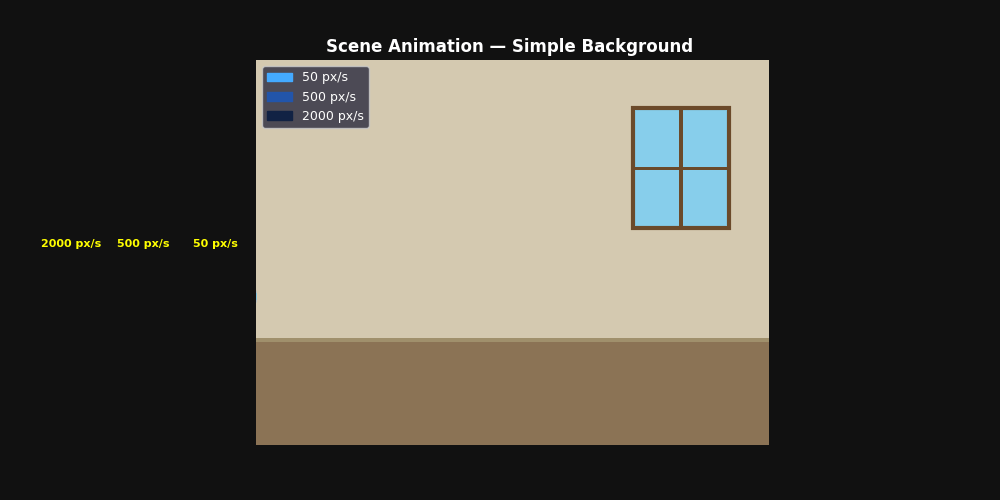

Saved: animation_high_texture.gif


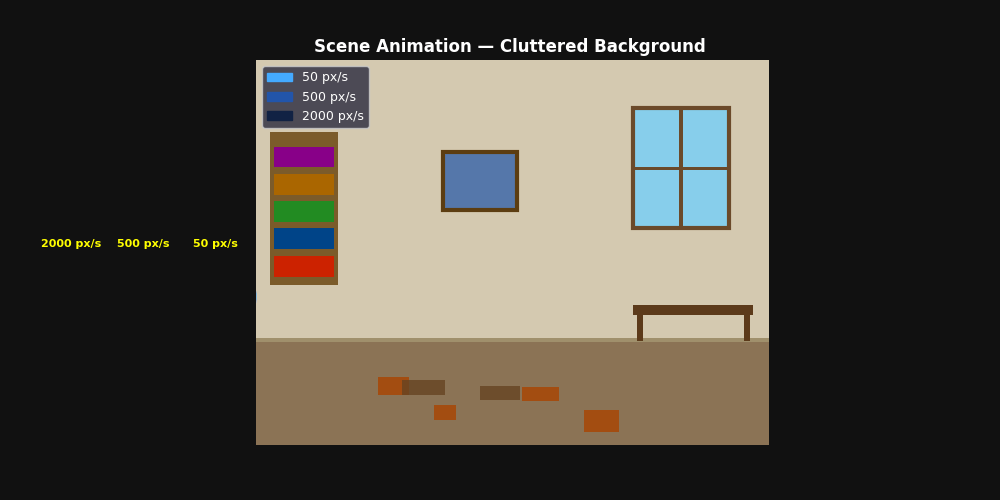


Animation complete!
Saved: cis_vs_dvs_low_texture.gif


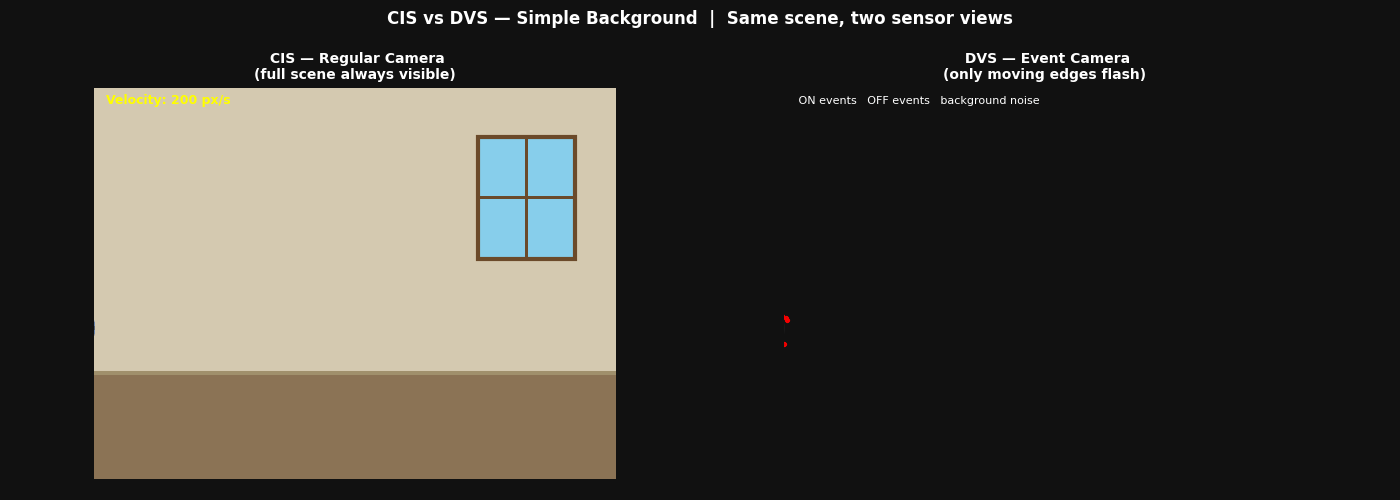

Saved: cis_vs_dvs_high_texture.gif


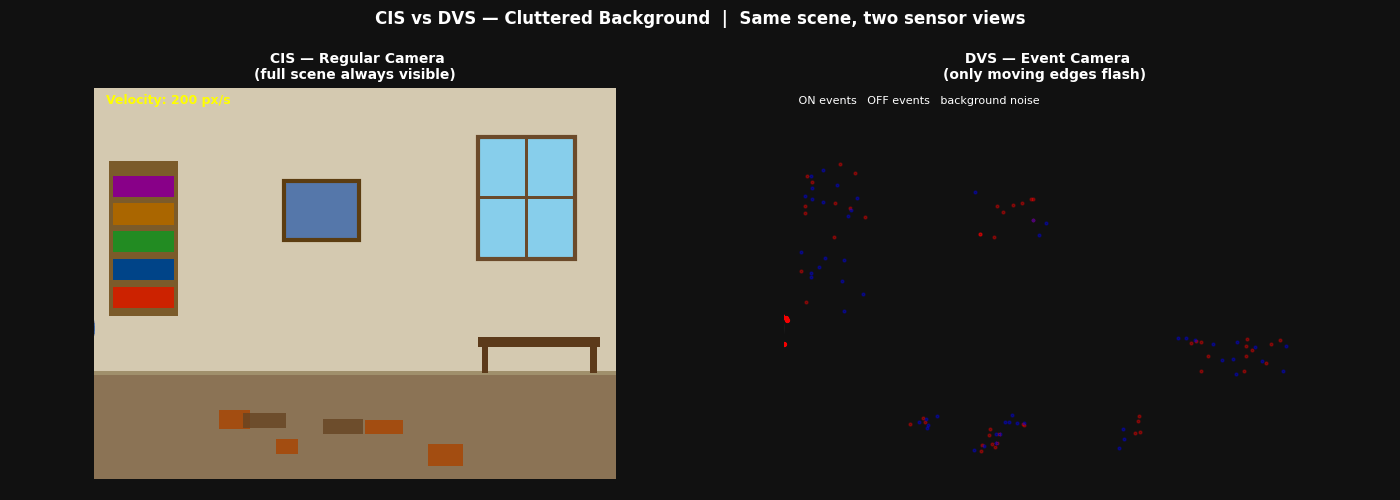


Animation complete!


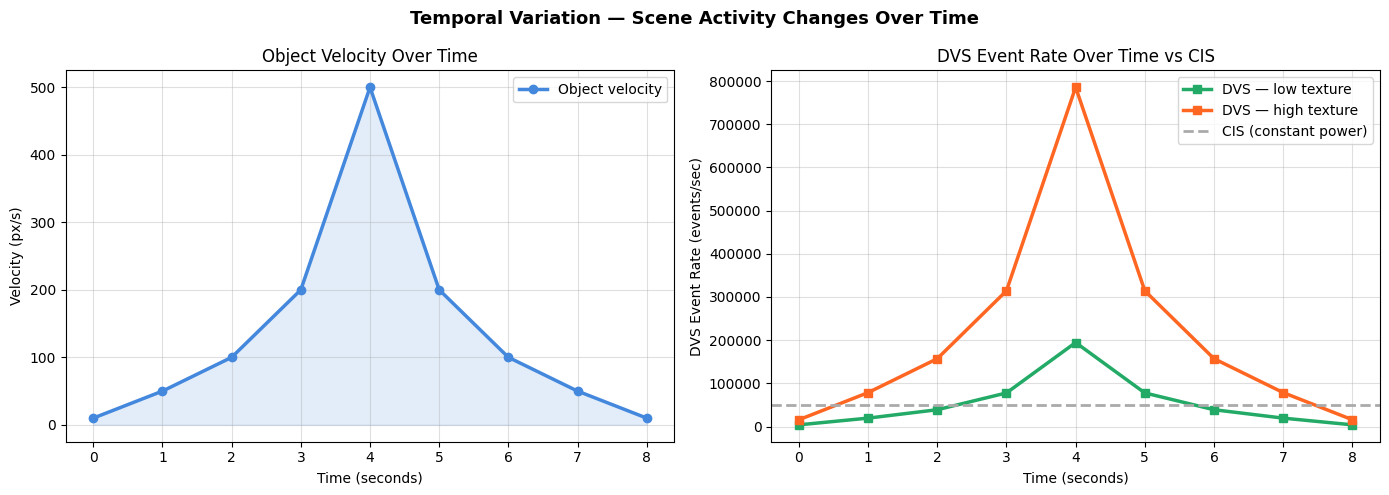

Saved: temporal_variation.png

Temporal Variation — Same object changing speed over time
 Time (s)  Velocity (px/s)  CIS Min FPS  DVS Events Low  DVS Events High
        0               10          2.0          3889.6          15716.8
        1               50         10.0         19448.0          78584.0
        2              100         20.0         38896.0         157168.0
        3              200         40.0         77792.0         314336.0
        4              500        100.0        194480.0         785840.0
        5              200         40.0         77792.0         314336.0
        6              100         20.0         38896.0         157168.0
        7               50         10.0         19448.0          78584.0
        8               10          2.0          3889.6          15716.8

SCENE MODEL OUTPUT

CIS: Minimum Frame Rate Requirements
 Object Size (px)  Velocity (px/s)  Min FPS Required          Note
               25               10               4.0 → F

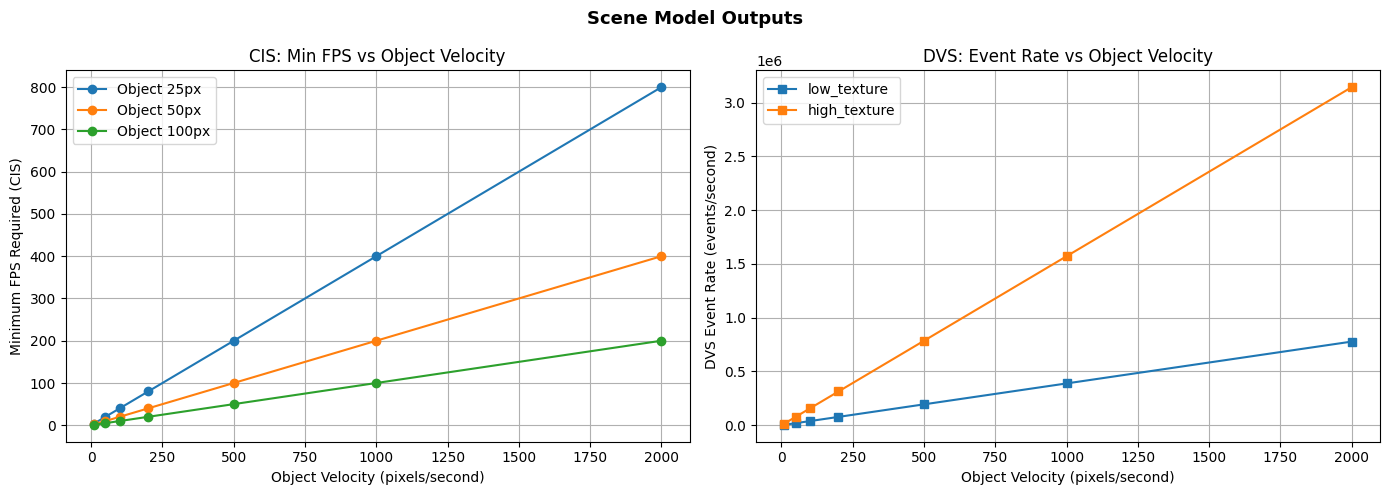


Scene model complete!


In [ ]:
#scene model


object_sizes   = [25, 50, 100]
velocities     = [10, 50, 100, 200, 500, 1000, 2000]
velocities_viz = [50, 500, 2000]
safety_factor  = 10
false_pos_rate = 0.10
ANIM_BG       = "low_texture"
ANIM_OBJ_SIZE = 50

backgrounds = {
    "low_texture":  0.05,  # plain background
    "high_texture": 0.40   # cluttered background
}

scene_width  = 640
scene_height = 480
light_wm2    = 5.0


def compute_fps_min(obj_speed, obj_size, safety=10):
    fps = (obj_speed / obj_size) * safety
    return round(fps, 2)

def compute_event_rate(obj_speed, obj_size, bg_edge_density, fp_rate=0.10):
    edge_length = 4 * obj_size
    obj_events  = edge_length * obj_speed
    bg_events   = bg_edge_density * scene_width * scene_height * 0.01 * obj_speed
    total       = (obj_events + bg_events) * (1 + fp_rate)
    return round(total, 1)

def compute_min_snr(obj_contrast, noise_floor=1.0):
    snr = 20 * np.log10(obj_contrast / noise_floor)
    return round(snr, 2)

#Actual image/animation

def draw_room(ax, bg_type):
    ax.add_patch(patches.Rectangle((0, 0), scene_width, 130,
                 facecolor="#8B7355", zorder=1))
    ax.add_patch(patches.Rectangle((0, 130), scene_width, 350,
                 facecolor="#D4C9B0", zorder=1))
    ax.add_patch(patches.Rectangle((0, 128), scene_width, 5,
                 facecolor="#A0906C", zorder=2))
    ax.add_patch(patches.Rectangle((470, 270), 120, 150,
                 facecolor="#87CEEB", zorder=2))
    ax.add_patch(patches.Rectangle((470, 270), 120, 150,
                 facecolor="none", edgecolor="#6B4A2A", linewidth=3, zorder=3))
    ax.add_patch(patches.Rectangle((528, 270), 4, 150,
                 facecolor="#6B4A2A", zorder=3))
    ax.add_patch(patches.Rectangle((470, 343), 120, 4,
                 facecolor="#6B4A2A", zorder=3))

    if bg_type == "high_texture":
        ax.add_patch(patches.Rectangle((18, 200), 85, 190,
                     facecolor="#7B5B2A", zorder=2))
        for i, c in enumerate(["#CC2200","#004488","#228B22","#AA6600","#880088"]):
            ax.add_patch(patches.Rectangle((23, 210 + i*34), 75, 26,
                         facecolor=c, zorder=3))
        ax.add_patch(patches.Rectangle((470, 162), 150, 12,
                     facecolor="#5C3A1A", zorder=2))
        for tx in [475, 608]:
            ax.add_patch(patches.Rectangle((tx, 130), 8, 34,
                         facecolor="#5C3A1A", zorder=2))
        ax.add_patch(patches.Rectangle((235, 295), 88, 68,
                     facecolor="#5577AA", zorder=2))
        ax.add_patch(patches.Rectangle((233, 293), 92, 72,
                     facecolor="none", edgecolor="#5C3D11", linewidth=3, zorder=3))
        np.random.seed(7)
        for _ in range(6):
            rx = np.random.uniform(130, 430)
            ry = np.random.uniform(15, 75)
            rw = np.random.uniform(25, 55)
            rh = np.random.uniform(12, 28)
            rc = np.random.choice(["#AA4400","#334455","#556633","#664422"])
            ax.add_patch(patches.Rectangle((rx, ry), rw, rh,
                         facecolor=rc, alpha=0.8, zorder=2))

# Animation  Moving Sphere at  Velocities

if __name__ == '__main__':

    anim_velocities = [50, 500, 2000]
    sphere_r        = 50
    sphere_cy       = 185
    n_frames        = 80
    fps_anim        = 20
    colours         = ["#44AAFF", "#2255AA", "#112244"]

    for bg_key, bg_label in [("low_texture",  "Simple Background "),
                              ("high_texture", "Cluttered Background ")]:

        fig_a, ax_a = plt.subplots(figsize=(10, 5))
        fig_a.patch.set_facecolor("#111111")
        ax_a.set_xlim(0, scene_width)
        ax_a.set_ylim(0, scene_height)
        ax_a.set_aspect("equal")
        ax_a.axis("off")
        ax_a.set_title(f"Scene Animation — {bg_label}",
                       color="white", fontsize=12, fontweight="bold")

        draw_room(ax_a, bg_key)

        sphere_patches = []
        for i, vel in enumerate(anim_velocities):
            shadow = patches.Ellipse((-200, 105), sphere_r*1.4, sphere_r*0.22,
                                      facecolor="black", alpha=0.18, zorder=3)
            body   = Circle((-200, sphere_cy), sphere_r,
                             color=colours[i], zorder=5)
            shine  = Circle((-200 - sphere_r*0.33, sphere_cy + sphere_r*0.33),
                             sphere_r*0.30, color="white", alpha=0.5, zorder=6)
            txt    = ax_a.text(-200, sphere_cy + sphere_r + 12,
                               f"{vel} px/s", color="yellow",
                               fontsize=8, fontweight="bold",
                               ha="center", zorder=9)
            for p in [shadow, body, shine]:
                ax_a.add_patch(p)
            sphere_patches.append((shadow, body, shine, txt))

        ax_a.legend(
            handles=[patches.Patch(color=colours[i], label=f"{v} px/s")
                     for i, v in enumerate(anim_velocities)],
            loc="upper left", facecolor="#2a2a3e",
            labelcolor="white", fontsize=9
        )

        def make_update_3a(patch_list, vels, nr, sw, sr):
            def update(frame):
                for idx, (shadow, body, shine, txt) in enumerate(patch_list):
                    vel         = vels[idx]
                    speed_scale = vel / max(vels)
                    start_x     = -sr - idx * 90
                    cx = start_x + (frame / nr) * (sw + sr * 4) * speed_scale * 3
                    if cx > sw + sr:
                        cx = -sr
                    body.center   = (cx, sphere_cy)
                    shine.center  = (cx - sr*0.33, sphere_cy + sr*0.33)
                    shadow.center = (cx, 105)

                    txt.set_position((cx, sphere_cy + sr + 12))
                return [p for group in patch_list for p in group]
            return update

        ani = FuncAnimation(
            fig_a,
            make_update_3a(sphere_patches, anim_velocities,
                           n_frames, scene_width, sphere_r),
            frames=n_frames,
            interval=1000 // fps_anim,
            blit=False
        )

        fname = f"animation_{bg_key}.gif"
        ani.save(fname, writer=PillowWriter(fps=fps_anim))
        plt.close(fig_a)
        print(f"Saved: {fname}")
        display(Image(filename=fname))

    print("\nAnimation complete!")


    demo_vel = 200

    for bg_key, bg_label in [("low_texture",  "Simple Background"),
                              ("high_texture", "Cluttered Background")]:

        fig_b, (ax_cis, ax_dvs) = plt.subplots(1, 2, figsize=(14, 5))
        fig_b.patch.set_facecolor("#111111")

        # CIS
        ax_cis.set_xlim(0, scene_width)
        ax_cis.set_ylim(0, scene_height)
        ax_cis.set_aspect("equal")
        ax_cis.axis("off")
        ax_cis.set_title(" CIS — Regular Camera\n(full scene always visible)",
                         color="white", fontsize=10, fontweight="bold")
        draw_room(ax_cis, bg_key)

        cis_shadow = patches.Ellipse((-200, 105), sphere_r*1.4, sphere_r*0.22,
                                      facecolor="black", alpha=0.18, zorder=3)

        cis_body   = Circle((-200, sphere_cy), sphere_r,
                             color="#2255AA", zorder=5)
        cis_shine  = Circle((-200 - sphere_r*0.33, sphere_cy + sphere_r*0.33),
                             sphere_r*0.30, color="white", alpha=0.5, zorder=6)
        for p in [cis_shadow, cis_body, cis_shine]:
            ax_cis.add_patch(p)
        ax_cis.text(14, scene_height - 20, f"Velocity: {demo_vel} px/s",
                    color="yellow", fontsize=9, fontweight="bold", zorder=9)

        # DVS
        ax_dvs.set_xlim(0, scene_width)
        ax_dvs.set_ylim(0, scene_height)
        ax_dvs.set_aspect("equal")
        ax_dvs.axis("off")
        ax_dvs.set_facecolor("black")
        ax_dvs.set_title(" DVS — Event Camera\n(only moving edges flash)",
                         color="white", fontsize=10, fontweight="bold")
        ax_dvs.text(14, scene_height - 20,
                    " ON events   OFF events   background noise",
                    color="white", fontsize=8, zorder=9)

        dvs_on  = ax_dvs.scatter([], [], s=8, c="red",  alpha=0.9, zorder=8)
        dvs_off = ax_dvs.scatter([], [], s=8, c="blue", alpha=0.9, zorder=8)

        # background noise cluttered only
        np.random.seed(42)
        if bg_key == "high_texture":
            shelf_x = np.random.uniform(18,  103, 100)
            shelf_y = np.random.uniform(200, 390, 100)
            table_x = np.random.uniform(470, 620,  50)
            table_y = np.random.uniform(162, 174,  50)
            leg_x   = np.random.uniform(475, 616,  30)
            leg_y   = np.random.uniform(130, 162,  30)
            pic_x   = np.random.uniform(233, 325,  50)
            pic_y   = np.random.uniform(293, 365,  50)
            np.random.seed(7)
            floor_x_list, floor_y_list = [], []
            for _ in range(6):
                rx = np.random.uniform(130, 430)
                ry = np.random.uniform(15,   75)
                rw = np.random.uniform(25,   55)
                rh = np.random.uniform(12,   28)
                bx = np.random.uniform(rx, rx+rw, 20)
                by = np.random.uniform(ry, ry+rh, 20)
                floor_x_list.append(bx)
                floor_y_list.append(by)
            floor_x    = np.concatenate(floor_x_list)
            floor_y    = np.concatenate(floor_y_list)
            np.random.seed(42)
            all_bg_x   = np.concatenate([shelf_x, table_x, leg_x, pic_x, floor_x])
            all_bg_y   = np.concatenate([shelf_y, table_y, leg_y, pic_y, floor_y])
            n_bg_total = len(all_bg_x)
            dvs_bg_on  = ax_dvs.scatter([], [], s=4, c="red",  alpha=0.35, zorder=6)
            dvs_bg_off = ax_dvs.scatter([], [], s=4, c="blue", alpha=0.35, zorder=6)
        else:
            all_bg_x   = np.array([])
            all_bg_y   = np.array([])
            n_bg_total = 0
            dvs_bg_on  = ax_dvs.scatter([], [], s=4, c="red",  alpha=0.0, zorder=6)
            dvs_bg_off = ax_dvs.scatter([], [], s=4, c="blue", alpha=0.0, zorder=6)

        dvs_outline = Circle((-200, sphere_cy), sphere_r,
                              fill=False, edgecolor="#ffffff15",
                              linewidth=1, zorder=4)
        ax_dvs.add_patch(dvs_outline)

        def make_update_3b(n_fr, sw, sr, vel, bg, bg_x, bg_y, n_bg):
            def update(frame):
                np.random.seed(frame)
                cx = -sr + (frame / n_fr) * (sw + sr * 2.5)
                if cx > sw + sr:
                    cx = -sr

                cis_body.center   = (cx, sphere_cy)
                cis_shine.center  = (cx - sr*0.33, sphere_cy + sr*0.33)
                cis_shadow.center = (cx, 105)

                dvs_outline.center= (cx, sphere_cy)

                n_ev  = max(10, int(vel / 25))
                on_a  = np.random.uniform(-np.pi/2, np.pi/2, n_ev)
                on_x  = cx + sr * np.cos(on_a) + np.random.uniform(-5, 5, n_ev)
                on_y  = sphere_cy + sr * np.sin(on_a) + np.random.uniform(-5, 5, n_ev)
                off_a = np.random.uniform(np.pi/2, 3*np.pi/2, n_ev)
                off_x = cx + sr * np.cos(off_a) + np.random.uniform(-5, 5, n_ev)
                off_y = sphere_cy + sr * np.sin(off_a) + np.random.uniform(-5, 5, n_ev)

                dvs_on.set_offsets(np.c_[on_x, on_y])
                dvs_off.set_offsets(np.c_[off_x, off_y])

                if bg == "high_texture" and n_bg > 0:
                    n_show = max(1, int(n_bg * 0.30))
                    idx    = np.random.choice(n_bg, n_show, replace=False)
                    half   = n_show // 2
                    dvs_bg_on.set_offsets(
                        np.c_[bg_x[idx[:half]] + np.random.uniform(-2, 2, half),
                              bg_y[idx[:half]] + np.random.uniform(-2, 2, half)])
                    dvs_bg_off.set_offsets(
                        np.c_[bg_x[idx[half:]] + np.random.uniform(-2, 2, n_show-half),
                              bg_y[idx[half:]] + np.random.uniform(-2, 2, n_show-half)])
                else:
                    dvs_bg_on.set_offsets(np.empty((0, 2)))
                    dvs_bg_off.set_offsets(np.empty((0, 2)))

                return [cis_body, cis_shine, cis_shadow,
                        dvs_outline, dvs_on, dvs_off, dvs_bg_on, dvs_bg_off]
            return update

        ani_b = FuncAnimation(
            fig_b,
            make_update_3b(n_frames, scene_width, sphere_r,
                           demo_vel, bg_key, all_bg_x, all_bg_y, n_bg_total),
            frames=n_frames,
            interval=1000 // fps_anim,
            blit=False
        )

        fig_b.suptitle(
            f"CIS vs DVS — {bg_label}  |  Same scene, two sensor views",
            color="white", fontsize=12, fontweight="bold"
        )
        plt.tight_layout(pad=1.5)

        fname_b = f"cis_vs_dvs_{bg_key}.gif"
        ani_b.save(fname_b, writer=PillowWriter(fps=fps_anim))
        plt.close(fig_b)
        print(f"Saved: {fname_b}")
        display(Image(filename=fname_b))

    print("\nAnimation complete!")

#temporal variation

    time_steps         = [0, 1, 2, 3, 4, 5, 6, 7, 8]
    velocity_over_time = [10, 50, 100, 200, 500, 200, 100, 50, 10]
    obj_size           = 50

    fps_over_time         = [compute_fps_min(v, obj_size, safety_factor) for v in velocity_over_time]
    events_low_over_time  = [compute_event_rate(v, obj_size, 0.05, false_pos_rate) for v in velocity_over_time]
    events_high_over_time = [compute_event_rate(v, obj_size, 0.40, false_pos_rate) for v in velocity_over_time]

    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

    ax1 = axes2[0]
    ax1.plot(time_steps, velocity_over_time, marker='o',
             color="#4488DD", linewidth=2.5, label="Object velocity")
    ax1.fill_between(time_steps, velocity_over_time, alpha=0.15, color="#4488DD")
    ax1.set_xlabel("Time (seconds)")
    ax1.set_ylabel("Velocity (px/s)")
    ax1.set_title("Object Velocity Over Time")
    ax1.legend()
    ax1.grid(True, alpha=0.4)

    ax2 = axes2[1]
    ax2.plot(time_steps, events_low_over_time,  marker='s',
             color="#22AA66", linewidth=2.5, label="DVS — low texture")
    ax2.plot(time_steps, events_high_over_time, marker='s',
             color="#FF6622", linewidth=2.5, label="DVS — high texture")
    cis_line = [max(fps_over_time) * 500] * len(time_steps)
    ax2.axhline(y=cis_line[0], color="#AAAAAA", linewidth=2,
                linestyle="--", label="CIS (constant power)")
    ax2.set_xlabel("Time (seconds)")
    ax2.set_ylabel("DVS Event Rate (events/sec)")
    ax2.set_title("DVS Event Rate Over Time vs CIS")
    ax2.legend()
    ax2.grid(True, alpha=0.4)

    plt.suptitle("Temporal Variation — Scene Activity Changes Over Time",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("temporal_variation.png", dpi=150)
    plt.show()
    print("Saved: temporal_variation.png")

    print("\nTemporal Variation — Same object changing speed over time")
    print("=" * 70)
    temporal_rows = []
    for t, vel in zip(time_steps, velocity_over_time):
        fps   = compute_fps_min(vel, obj_size, safety_factor) if vel > 0 else 0
        e_low = compute_event_rate(vel, obj_size, 0.05, false_pos_rate)
        e_high= compute_event_rate(vel, obj_size, 0.40, false_pos_rate)
        temporal_rows.append({
            "Time (s)"        : t,
            "Velocity (px/s)" : vel,
            "CIS Min FPS"     : fps,
            "DVS Events Low"  : e_low,
            "DVS Events High" : e_high
        })
    temporal_df = pd.DataFrame(temporal_rows)
    print(temporal_df.to_string(index=False))

#o/p table

    print("\n" + "=" * 65)
    print("SCENE MODEL OUTPUT")
    print("=" * 65)

    cis_rows = []
    for obj_size in object_sizes:
        for speed in velocities:
            fps = compute_fps_min(speed, obj_size, safety_factor)
            cis_rows.append({
                "Object Size (px)": obj_size,
                "Velocity (px/s)":  speed,
                "Min FPS Required": fps,
                "Note": "→ For ModuCIS"
            })
    cis_df = pd.DataFrame(cis_rows)
    print("\nCIS: Minimum Frame Rate Requirements")
    print(cis_df.to_string(index=False))

    print("\n" + "=" * 65)
    print("DVS: Predicted Event Rates")
    print("=" * 65)

    dvs_rows = []
    for bg_name, bg_density in backgrounds.items():
        for obj_size in object_sizes:
            for speed in velocities:
                evt_rate = compute_event_rate(speed, obj_size, bg_density, false_pos_rate)
                dvs_rows.append({
                    "Background":        bg_name,
                    "Object Size (px)":  obj_size,
                    "Velocity (px/s)":   speed,
                    "Event Rate (ev/s)": evt_rate,
                    "Note": "→ For DVS model"
                })
    dvs_df = pd.DataFrame(dvs_rows)
    print("\nDVS: Predicted Event Rates")
    print(dvs_df.to_string(index=False))

    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

    ax1 = axes3[0]
    for obj_size in object_sizes:
        fps_vals = [compute_fps_min(v, obj_size, safety_factor) for v in velocities]
        ax1.plot(velocities, fps_vals, marker='o', label=f"Object {obj_size}px")
    ax1.set_xlabel("Object Velocity (pixels/second)")
    ax1.set_ylabel("Minimum FPS Required (CIS)")
    ax1.set_title("CIS: Min FPS vs Object Velocity")
    ax1.legend()
    ax1.grid(True)

    ax2 = axes3[1]
    for bg_name, bg_density in backgrounds.items():
        evt_vals = [compute_event_rate(v, 50, bg_density, false_pos_rate)
                    for v in velocities]
        ax2.plot(velocities, evt_vals, marker='s', label=bg_name)
    ax2.set_xlabel("Object Velocity (pixels/second)")
    ax2.set_ylabel("DVS Event Rate (events/second)")
    ax2.set_title("DVS: Event Rate vs Object Velocity")
    ax2.legend()
    ax2.grid(True)

    plt.suptitle("Scene Model Outputs", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("scene_model_outputs.png", dpi=150)
    plt.show()

    print("\nScene model complete!")
